In [3]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
#read the dataset
data = pd.read_csv('height-weight.csv')

In [6]:
#convert data into a dataframe
df= pd.DataFrame(data)

In [5]:
data.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

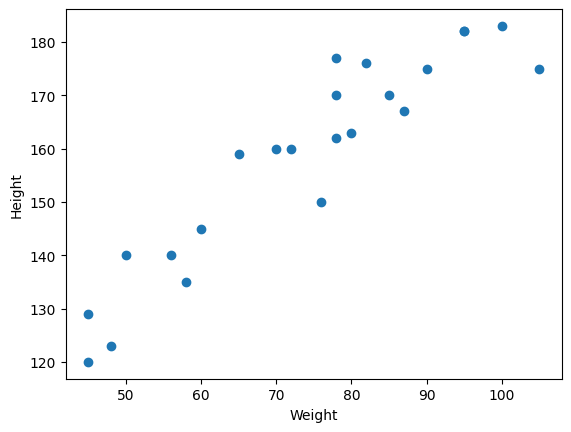

In [9]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [24]:
#Divide features into independent and dependent features
X = df[["Weight"]] #independent
y = df["Height"] #depependent

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
#Split data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=8)

In [27]:
X.shape, X_train.shape, X_test.shape, y.shape, y_train.shape, y_test.shape

((23, 1), (18, 1), (5, 1), (23,), (18,), (5,))

In [28]:
#Standardise the train independent dat
from sklearn.preprocessing import StandardScaler


In [29]:
scaler = StandardScaler()

In [30]:
X_train_scaled = scaler.fit_transform(X_train)

In [31]:
X_train_scaled

array([[ 1.86287776],
       [-1.15060097],
       [ 0.60269575],
       [-1.26018201],
       [ 0.87664836],
       [ 0.05479052],
       [-0.71227679],
       [ 0.27395261],
       [ 1.58892515],
       [-1.42455358],
       [ 0.38353366],
       [-0.82185783],
       [ 1.31497254],
       [ 0.38353366],
       [ 0.38353366],
       [-0.32874313],
       [-1.42455358],
       [-0.60269575]])

In [32]:
X_test_scaled = scaler.transform(X_test)

In [33]:
X_test_scaled

array([[ 0.4931147 ],
       [ 1.04101992],
       [-0.05479052],
       [ 1.31497254],
       [ 0.76706731]])

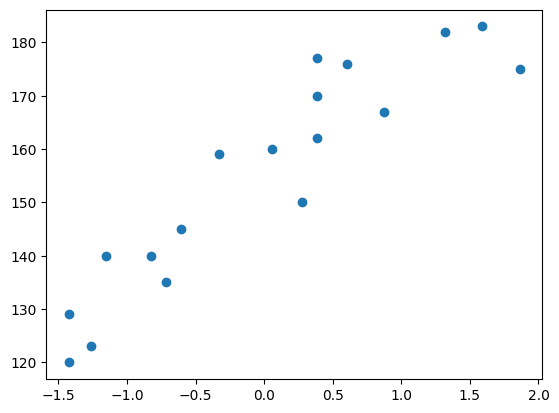

In [34]:
plt.scatter(X_train_scaled,y_train)

In [35]:
#Train the simple Linear regression model
from sklearn.linear_model import LinearRegression

In [36]:
regressor = LinearRegression()

In [37]:
regressor.fit(X_train_scaled,y_train)

LinearRegression()

In [38]:
regressor.coef_

array([18.44309859])

In [39]:
regressor.intercept_

np.float64(155.16666666666666)

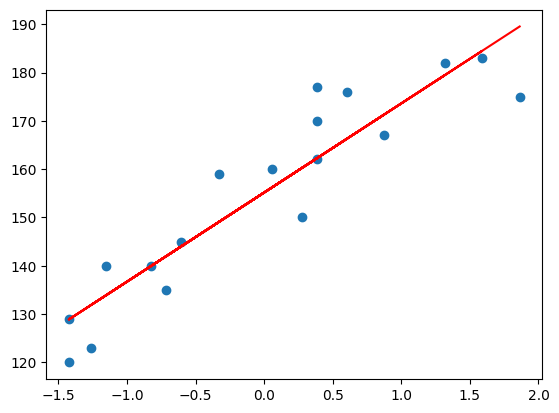

In [42]:
plt.scatter(X_train_scaled, y_train)
plt.plot(X_train_scaled,regressor.predict(X_train_scaled),'r')

In [45]:
#predict y for the test data
y_pred = regressor.predict(X_test_scaled)

In [44]:
y_pred, y_test

(array([164.26122971, 174.36629976, 154.15615966, 179.41883478,
        169.31376473]),
 6     163
 7     175
 4     160
 11    182
 14    170
 Name: Height, dtype: int64)

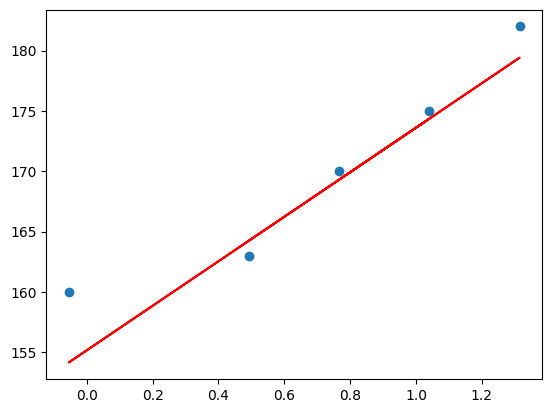

In [47]:
plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled, y_pred,'r')


In [48]:
#Performance Matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("Mse: ", mse," mae: ", mae, " rmse: ",rmse)


Mse:  8.655215803320909  mae:  2.2012341561040727  rmse:  2.941974813508931


In [49]:
# R Squared score rss
from sklearn.metrics import r2_score
print("r2_score: ", r2_score(y_test, y_pred))

r2_score:  0.8639117012056461


In [51]:
scaled_weight = scaler.transform([[80]])

c:\Users\pc\.conda\envs\heightweightenv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
pred_height = regressor.predict(scaled_weight)

In [56]:
print(f"Predicted height for 80 weight is {pred_height[0]}")

Predicted height for 80 weight is 164.26122970869466
